In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
sub_df = df[columns]
sub_df.head()


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


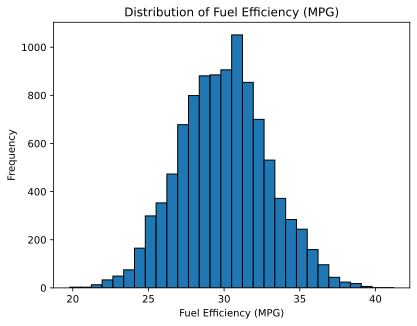

The graph doesn't have a long tail


In [14]:
plt.hist(sub_df['fuel_efficiency_mpg'], bins=30, edgecolor='black')
plt.title('Distribution of Fuel Efficiency (MPG)')
plt.xlabel('Fuel Efficiency (MPG)')
plt.ylabel('Frequency')
plt.show()
# EDA
print("The graph doesn't have a long tail")

In [15]:
# Q1 
missing_values = sub_df.isnull().sum()
# Display missing value counts
print("Missing values per column:")
print(missing_values)

# Identify specifically which column has missing values
missing_col = missing_values[missing_values > 0].index[0]
missing_count = missing_values[missing_col]

print(f"\nColumn with missing values: '{missing_col}' ({missing_count} missing entries)")

Missing values per column:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Column with missing values: 'horsepower' (877 missing entries)


In [17]:
# Q2
median = sub_df['horsepower'].median()
print(f"\nmedian (50% percentile) for variable 'horsepower': {median}")


median (50% percentile) for variable 'horsepower': 254.0


In [18]:
# DATA PREPARATION AND SPLITTING
n = len(sub_df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = sub_df.iloc[idx[:n_train]]
df_val = sub_df.iloc[idx[n_train:n_train + n_val]]
df_test = sub_df.iloc[idx[n_train + n_val:]]

In [21]:
# 1. Reset indices so row labels start from 0
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# 2. Extract target array (y) and drop target from feature DataFrames
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [28]:
# Q3
# Function to train linear regression without regularization
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

# Function to calculate RMSE
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

# Prepare features filling missing values with 0
def prepare_X_fill_0(df):
    df_num = df.copy()
    df_num['horsepower'] = df_num['horsepower'].fillna(0)
    return df_num.values

# Train and validate Model 1 (Fill with 0)
X_train_0 = prepare_X_fill_0(df_train)
w_0, w_0_rest = train_linear_regression(X_train_0, y_train)

X_val_0 = prepare_X_fill_0(df_val)
y_pred_0 = w_0 + X_val_0.dot(w_0_rest)

rmse_0 = rmse(y_val, y_pred_0)
print(f"RMSE (Fill with 0): {round(rmse_0, 3)}")

# Calculate mean from training data only to avoid data leakage
mean_hp = df_train['horsepower'].mean()

# Prepare features filling missing values with the calculated mean
def prepare_X_fill_mean(df, mean_val):
    df_num = df.copy()
    df_num['horsepower'] = df_num['horsepower'].fillna(mean_val)
    return df_num.values

# Train and validate Model 2 (Fill with mean)
X_train_mean = prepare_X_fill_mean(df_train, mean_hp)
w_mean, w_mean_rest = train_linear_regression(X_train_mean, y_train)

X_val_mean = prepare_X_fill_mean(df_val, mean_hp)
y_pred_mean = w_mean + X_val_mean.dot(w_mean_rest)

rmse_mean = rmse(y_val, y_pred_mean)
print(f"RMSE (Fill with mean): {round(rmse_mean, 3)}")

RMSE (Fill with 0): 2.205
RMSE (Fill with mean): 2.202


In [30]:
# Q4
# Function to train linear regression WITH regularization
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    
    # Add regularization to the diagonal of XTX
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

# We already have X_train_0 and X_val_0 prepared from Q3 (NAs filled with 0)
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

print("RMSE results for different values of r:")
print("-" * 40)

# Evaluate each r value
for r in r_values:
    # Train the model with regularization
    w_0, w_rest = train_linear_regression_reg(X_train_0, y_train, r=r)
    
    # Make predictions on the validation set
    y_pred = w_0 + X_val_0.dot(w_rest)
    
    # Calculate RMSE and round to 4 decimal digits
    rmse_val = rmse(y_val, y_pred)
    
    print(f"r: {r:<6} | RMSE: {round(rmse_val, 4)}")

RMSE results for different values of r:
----------------------------------------
r: 0      | RMSE: 2.2053
r: 0.01   | RMSE: 2.2058
r: 0.1    | RMSE: 2.2241
r: 1      | RMSE: 2.3492
r: 5      | RMSE: 2.4094
r: 10     | RMSE: 2.4195
r: 100    | RMSE: 2.4292


In [31]:
# Q5
# List of seeds to evaluate
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

n = len(sub_df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

for s in seeds:
    # 1. Shuffle and Split with the current seed
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train_s = sub_df.iloc[idx[:n_train]].copy()
    df_val_s = sub_df.iloc[idx[n_train:n_train + n_val]].copy()
    # We do not strictly need df_test_s for this question, but we slice it to match the logic
    
    # 2. Reset indices
    df_train_s = df_train_s.reset_index(drop=True)
    df_val_s = df_val_s.reset_index(drop=True)
    
    # 3. Extract targets
    y_train_s = df_train_s['fuel_efficiency_mpg'].values
    y_val_s = df_val_s['fuel_efficiency_mpg'].values
    
    del df_train_s['fuel_efficiency_mpg']
    del df_val_s['fuel_efficiency_mpg']
    
    # 4. Prepare features (Fill missing with 0)
    X_train_s = prepare_X_fill_0(df_train_s)
    X_val_s = prepare_X_fill_0(df_val_s)
    
    # 5. Train Model without regularization
    w_0_s, w_rest_s = train_linear_regression(X_train_s, y_train_s)
    
    # 6. Evaluate on Validation set
    y_pred_s = w_0_s + X_val_s.dot(w_rest_s)
    rmse_s = rmse(y_val_s, y_pred_s)
    
    rmse_scores.append(rmse_s)
    print(f"Seed {s}: RMSE = {round(rmse_s, 4)}")

# Calculate the standard deviation of all collected RMSE scores
std_rmse = np.std(rmse_scores)

print("-" * 30)
print(f"Standard Deviation: {round(std_rmse, 3)}")

Seed 0: RMSE = 2.2392
Seed 1: RMSE = 2.2021
Seed 2: RMSE = 2.1634
Seed 3: RMSE = 2.2044
Seed 4: RMSE = 2.2019
Seed 5: RMSE = 2.2458
Seed 6: RMSE = 2.2697
Seed 7: RMSE = 2.1908
Seed 8: RMSE = 2.2166
Seed 9: RMSE = 2.207
------------------------------
Standard Deviation: 0.029


In [32]:
#Q6
# 1. Set seed and split the data
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = sub_df.iloc[idx[:n_train]].copy()
df_val = sub_df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = sub_df.iloc[idx[n_train + n_val:]].copy()

# 2. Combine train and validation datasets
df_full_train = pd.concat([df_train, df_val])

# Reset indices
df_full_train = df_full_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# 3. Extract targets
y_full_train = df_full_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_full_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# 4. Prepare features (Fill missing values with 0)
X_full_train = prepare_X_fill_0(df_full_train)
X_test = prepare_X_fill_0(df_test)

# 5. Train the model on the full training dataset with regularization r=0.001
w_0_full, w_rest_full = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

# 6. Evaluate on the test dataset
y_pred_test = w_0_full + X_test.dot(w_rest_full)
rmse_test = rmse(y_test, y_pred_test)

print(f"RMSE on test dataset: {round(rmse_test, 3)}")

RMSE on test dataset: 2.236
